# Notebook 04 — Sliding Window Search

After thresholding we have a binary mask of suspected lane pixels. But the mask treats all white pixels equally — we don't yet know which ones belong to the **left** lane vs. the **right** lane. The sliding window algorithm groups pixels into per-lane collections.

The algorithm has two phases:

**Phase 1 — Find lane bases:**
Take a histogram of the bottom half of the mask. Each column's value is the count of white pixels in that column. The two highest peaks (one in the left half, one in the right half) are our starting x-positions for the left and right lanes.

**Phase 2 — Slide windows up:**
Place a window centered at each base. Find white pixels inside the window — those are lane pixels. Move the window up one step and re-center it on the mean x-position of the pixels we just found. Repeat until the top.

This is a 30-year-old algorithm but still surprisingly effective on highway scenes. Its main weaknesses are:
- Bad lane base if the histogram peak is wrong (e.g., heavy shadow on one side)
- Lost track if a window has too few pixels (a long dashed-line gap)

We'll address the second one in our temporal smoothing module.

## 1. Setup — load a sample and produce its threshold mask

Mask shape: (720, 720), lane pixels: 27408


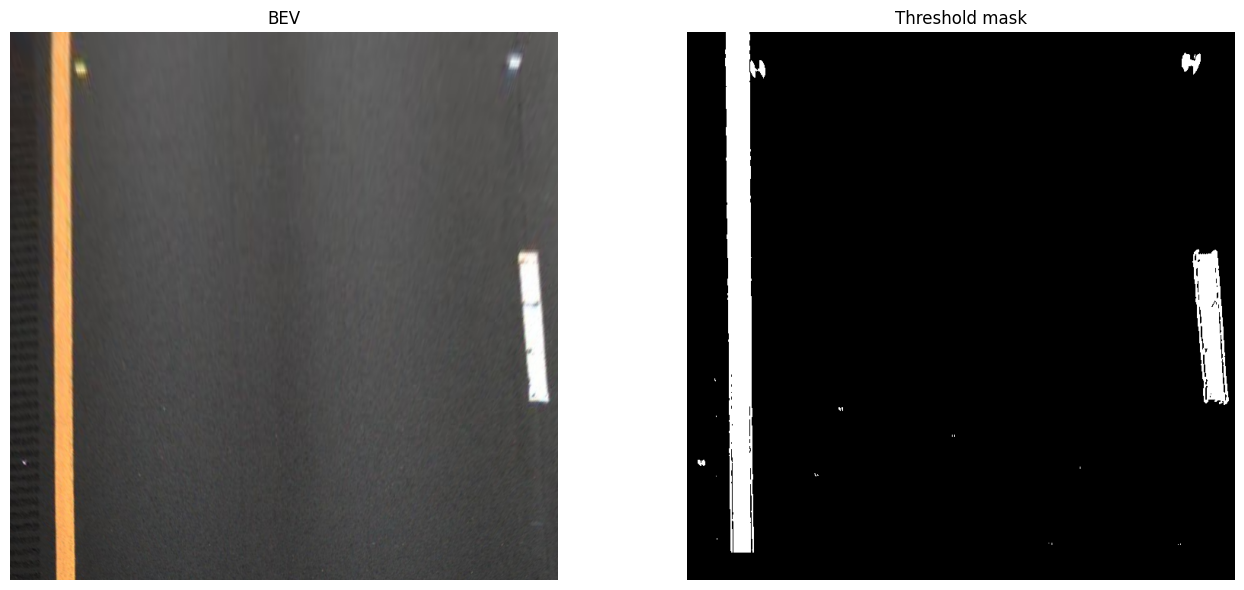

In [7]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tusimple_loader import TuSimpleDataset
from perspective import PerspectiveWarper
from thresholding import threshold_pipeline

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100

dataset = TuSimpleDataset(
    annotation_file=project_root / "data/tusimple/test_subset/test_label_subset.json",
    image_root=project_root / "data/tusimple/test_subset",
)
warper = PerspectiveWarper()

# Use sample 0 — clean, both lanes visible
sample = dataset[0]
img_rgb = cv2.cvtColor(cv2.imread(str(sample.image_path)), cv2.COLOR_BGR2RGB)
bev = warper.warp_image(img_rgb)
mask = threshold_pipeline(bev)

print(f"Mask shape: {mask.shape}, lane pixels: {(mask == 255).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bev); axes[0].set_title("BEV")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Threshold mask")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Histogram of bottom half — find lane bases

We sum white pixels along each column for the bottom half of the mask. The bottom half is used because:
- Lanes are most consistently visible near the camera
- The far end of the BEV has more warping artifacts
- Lanes are roughly vertical at the bottom (good signal in column histogram)

We then split the histogram in half: the left half's peak is the left lane's starting x-position, the right half's peak is the right lane's.

Left lane base x: 61
Right lane base x: 684
Lane separation: 623 pixels


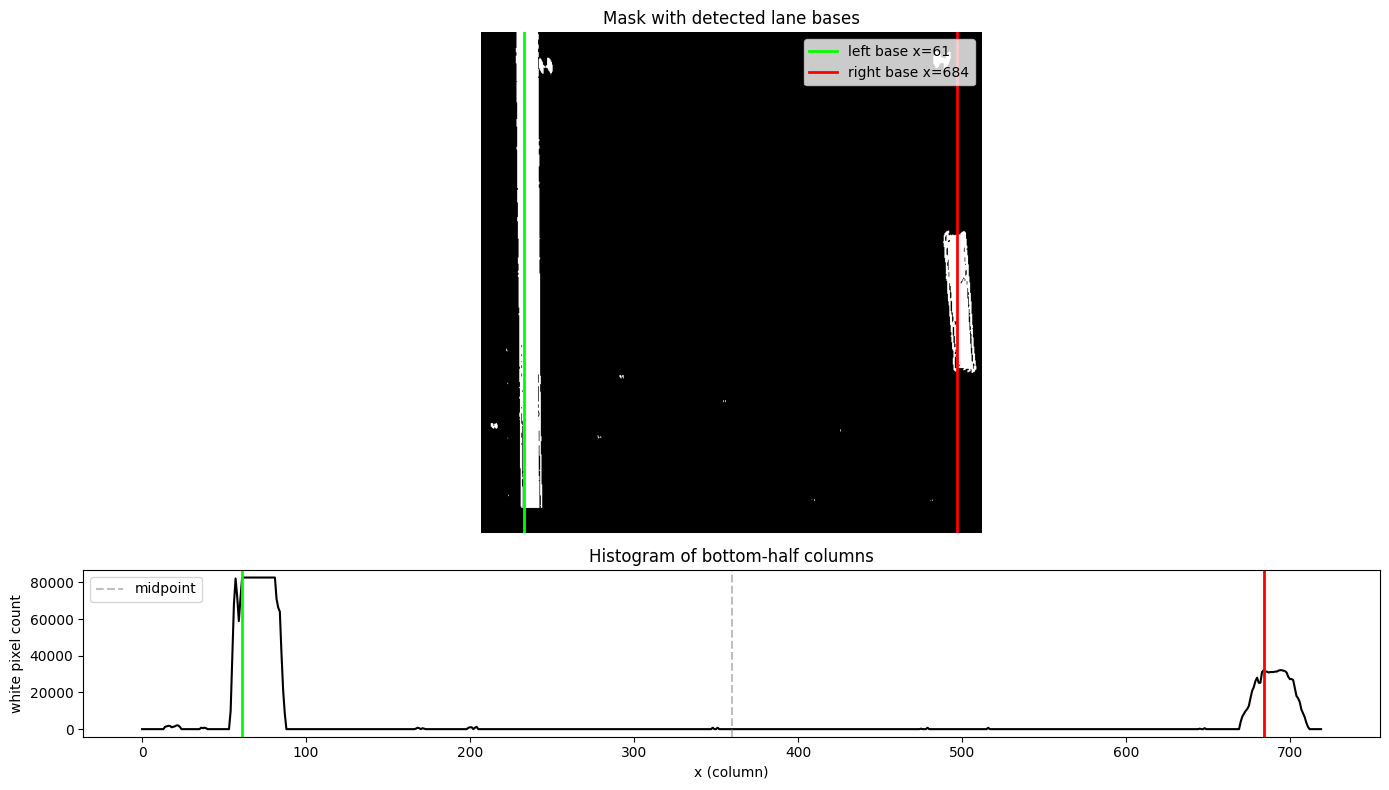

In [8]:
def find_lane_bases(mask: np.ndarray) -> tuple[int, int, np.ndarray]:
    """Find starting x-positions of the left and right lanes.

    Returns:
        (left_x, right_x, histogram)
    """
    H, W = mask.shape
    
    # Sum each column over the bottom half of the mask
    bottom_half = mask[H // 2:, :]
    histogram = np.sum(bottom_half, axis=0)  # shape (W,)
    
    # Find peak in left half and right half separately
    midpoint = W // 2
    left_x = int(np.argmax(histogram[:midpoint]))
    right_x = int(np.argmax(histogram[midpoint:]) + midpoint)
    
    return left_x, right_x, histogram


left_base, right_base, hist = find_lane_bases(mask)
print(f"Left lane base x: {left_base}")
print(f"Right lane base x: {right_base}")
print(f"Lane separation: {right_base - left_base} pixels")

# Visualize: histogram with peaks marked
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={"height_ratios": [3, 1]})
axes[0].imshow(mask, cmap="gray")
axes[0].axvline(left_base, color="lime", linewidth=2, label=f"left base x={left_base}")
axes[0].axvline(right_base, color="red", linewidth=2, label=f"right base x={right_base}")
axes[0].set_title("Mask with detected lane bases")
axes[0].legend(loc="upper right")
axes[0].axis("off")

axes[1].plot(hist, color="black")
axes[1].axvline(left_base, color="lime", linewidth=2)
axes[1].axvline(right_base, color="red", linewidth=2)
axes[1].axvline(mask.shape[1] // 2, color="gray", linestyle="--", alpha=0.5,
                label="midpoint")
axes[1].set_title("Histogram of bottom-half columns")
axes[1].set_xlabel("x (column)")
axes[1].set_ylabel("white pixel count")
axes[1].legend()
plt.tight_layout(); plt.show()

## 3. The sliding window walk

Starting from the lane bases, we stack windows upward. At each level:

1. Define a window: rectangle centered at current x, height `window_height`, width `2 * margin`
2. Find white pixels inside the window
3. If we found enough pixels (`min_pixels`), shift the next window's center to the mean x of those pixels
4. Otherwise, keep the same x for the next window (lane lost in this slice)

The output is two lists of pixel indices: one for the left lane, one for the right.

Tunable parameters (these need to be sensible for our 720x720 BEV):
- `n_windows` = 9: divides the image height into 9 slices (each ~80px tall)
- `margin` = 100: window half-width (so total window width is 200 pixels)
- `min_pixels` = 50: minimum pixel count to recenter the next window

In [9]:
def sliding_window_search(
    mask: np.ndarray,
    n_windows: int = 9,
    margin: int = 100,
    min_pixels: int = 50,
    base_min_count: int = 3000,
) -> dict:
    """Sliding window search with lane-detection validation.

    Improvements over baseline:
    - base_min_count: minimum histogram peak height to call a lane "detected".
      If the peak is too low, that lane is marked as None (not detected).
    - Returns left_detected and right_detected booleans.
    - When a lane is undetected, no windows are drawn and no pixels assigned.
    """
    H, W = mask.shape
    window_height = H // n_windows

    nonzero = mask.nonzero()
    nonzero_y = nonzero[0]
    nonzero_x = nonzero[1]

    # === Step 1: histogram of bottom half ===
    bottom_half = mask[H // 2:, :]
    histogram = np.sum(bottom_half, axis=0)
    midpoint = W // 2

    left_peak_value = histogram[:midpoint].max()
    right_peak_value = histogram[midpoint:].max()

    left_detected = left_peak_value >= base_min_count
    right_detected = right_peak_value >= base_min_count

    left_base = int(np.argmax(histogram[:midpoint])) if left_detected else None
    right_base = int(np.argmax(histogram[midpoint:]) + midpoint) if right_detected else None

    # === Step 2: walk windows up — only for detected lanes ===
    left_x_current = left_base
    right_x_current = right_base

    left_lane_inds = []
    right_lane_inds = []

    windows_left = []
    windows_right = []

    for window_idx in range(n_windows):
        win_y_low = H - (window_idx + 1) * window_height
        win_y_high = H - window_idx * window_height

        # Process left lane only if detected
        if left_detected:
            xl_low = left_x_current - margin
            xl_high = left_x_current + margin
            windows_left.append((xl_low, win_y_low, xl_high, win_y_high))

            good_left = (
                (nonzero_y >= win_y_low) & (nonzero_y < win_y_high)
                & (nonzero_x >= xl_low) & (nonzero_x < xl_high)
            ).nonzero()[0]
            left_lane_inds.append(good_left)

            if len(good_left) > min_pixels:
                left_x_current = int(np.mean(nonzero_x[good_left]))

        # Process right lane only if detected
        if right_detected:
            xr_low = right_x_current - margin
            xr_high = right_x_current + margin
            windows_right.append((xr_low, win_y_low, xr_high, win_y_high))

            good_right = (
                (nonzero_y >= win_y_low) & (nonzero_y < win_y_high)
                & (nonzero_x >= xr_low) & (nonzero_x < xr_high)
            ).nonzero()[0]
            right_lane_inds.append(good_right)

            if len(good_right) > min_pixels:
                right_x_current = int(np.mean(nonzero_x[good_right]))

    # Concatenate per-window indices (or empty array)
    left_concat = np.concatenate(left_lane_inds) if left_lane_inds else np.array([], dtype=int)
    right_concat = np.concatenate(right_lane_inds) if right_lane_inds else np.array([], dtype=int)

    return {
        "left_x_idx": nonzero_x[left_concat],
        "left_y_idx": nonzero_y[left_concat],
        "right_x_idx": nonzero_x[right_concat],
        "right_y_idx": nonzero_y[right_concat],
        "windows_left": windows_left,
        "windows_right": windows_right,
        "left_base": left_base,
        "right_base": right_base,
        "left_detected": left_detected,
        "right_detected": right_detected,
        "left_peak_value": int(left_peak_value),
        "right_peak_value": int(right_peak_value),
    }


result = sliding_window_search(mask)
print(f"Left lane pixels found: {len(result['left_x_idx'])}")
print(f"Right lane pixels found: {len(result['right_x_idx'])}")

Left lane pixels found: 21069
Right lane pixels found: 6304


## 4. Visualize windows and per-lane pixels

We color the lane pixels: blue = left lane, red = right lane. The green rectangles are the sliding windows. Watch how they shift left or right as they climb to track the lane curves.

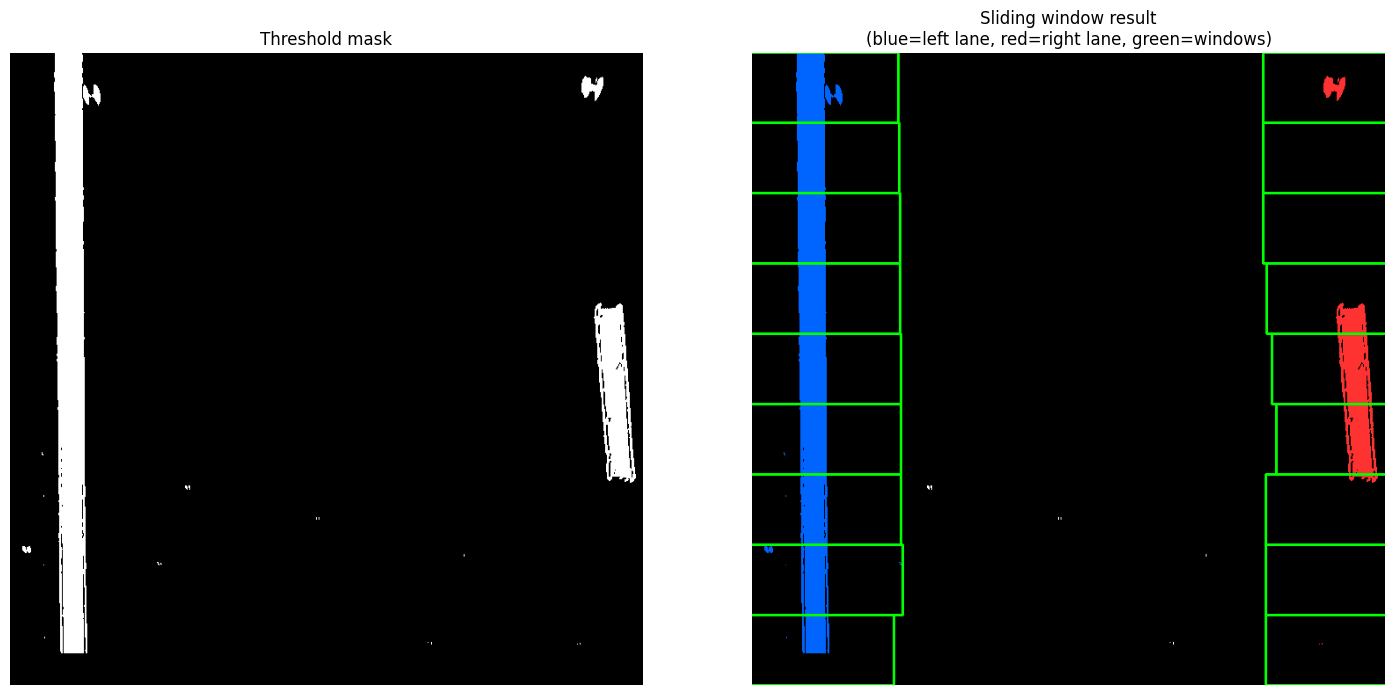

In [10]:
def visualize_sliding_window(mask: np.ndarray, result: dict) -> np.ndarray:
    """Render the sliding window result. Greys out undetected lanes."""
    img = np.dstack([mask, mask, mask])

    if result["left_detected"]:
        img[result["left_y_idx"], result["left_x_idx"]] = [0, 100, 255]
        for (x1, y1, x2, y2) in result["windows_left"]:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    if result["right_detected"]:
        img[result["right_y_idx"], result["right_x_idx"]] = [255, 50, 50]
        for (x1, y1, x2, y2) in result["windows_right"]:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return img


vis = visualize_sliding_window(mask, result)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(mask, cmap="gray"); axes[0].set_title("Threshold mask")
axes[1].imshow(vis); axes[1].set_title("Sliding window result\n(blue=left lane, red=right lane, green=windows)")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Test on multiple samples

Sliding window is sensitive to:
- **Bad histogram peaks** (e.g., heavy shadow can dominate histogram, putting the base in the wrong place)
- **Long dashed-line gaps** (windows lose track and stay where they were)
- **Lanes that aren't both clearly visible at the bottom** (one base is wildly off)

Let's see how it performs on the 6-sample diagnostic set.

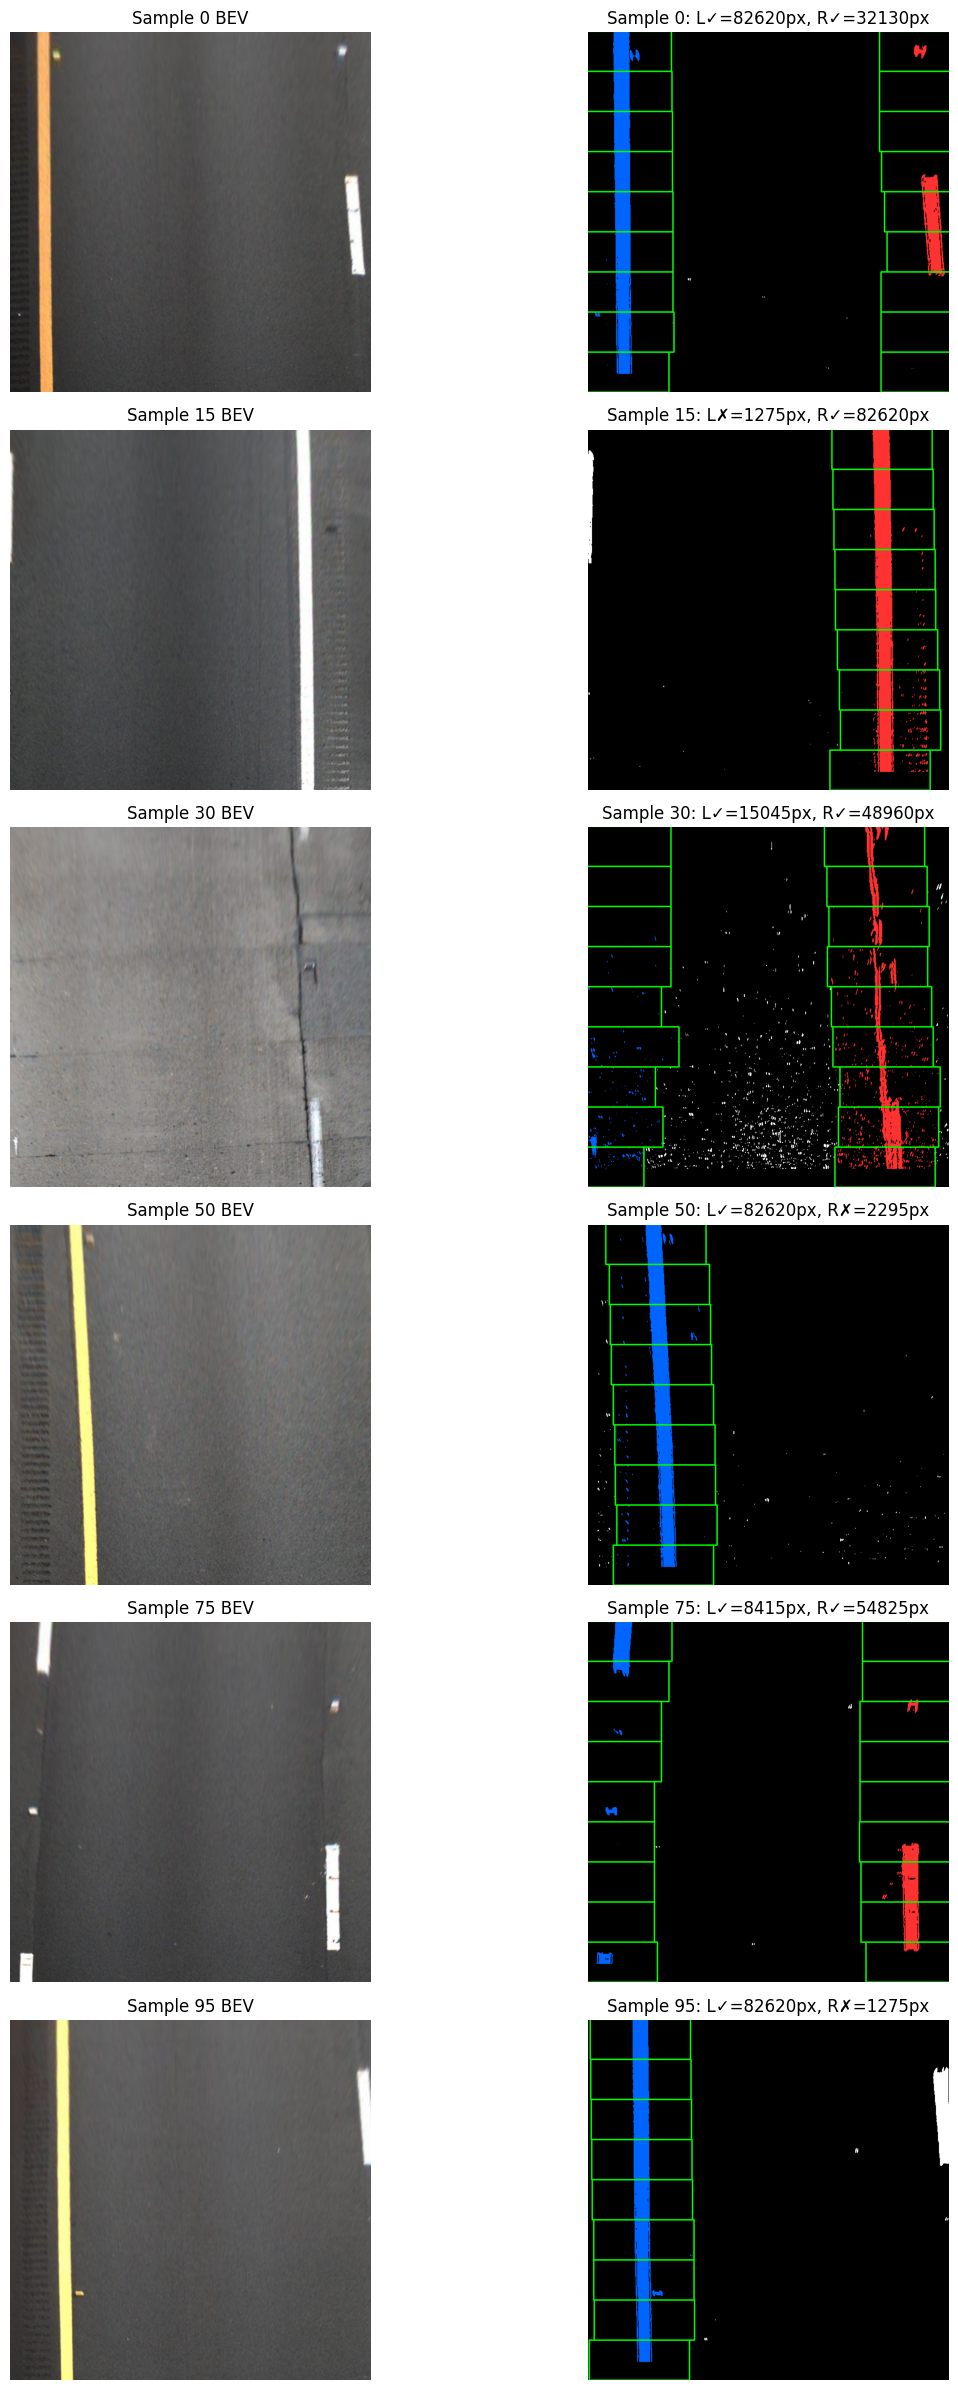

In [11]:
sample_indices = [0, 15, 30, 50, 75, 95]
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(14, 4 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    s = dataset[idx]
    img = cv2.cvtColor(cv2.imread(str(s.image_path)), cv2.COLOR_BGR2RGB)
    bev_i = warper.warp_image(img)
    mask_i = threshold_pipeline(bev_i)
    res_i = sliding_window_search(mask_i)
    vis_i = visualize_sliding_window(mask_i, res_i)

    L = "✓" if res_i["left_detected"] else "✗"
    R = "✓" if res_i["right_detected"] else "✗"
    
    axes[row, 0].imshow(bev_i); axes[row, 0].set_title(f"Sample {idx} BEV")
    axes[row, 1].imshow(vis_i)
    axes[row, 1].set_title(
        f"Sample {idx}: L{L}={res_i['left_peak_value']}px, R{R}={res_i['right_peak_value']}px"
    )
    for ax in axes[row]: ax.axis("off")

plt.tight_layout(); plt.show()